# Task 09 - Model Optimization and Hyperparameter Tuning

**Name:** Malaika Noor

**Objective:** Optimize a machine learning model using GridSearchCV, Cross Validation, Feature Importance Analysis, Learning Curves, and compare results before and after optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Create Sample Dataset

In [2]:
data = {
    "Clients":[10,15,20,25,30,35,40,45,50,55,60,65,70,75,80],
    "Team_Size":[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16],
    "Duration":[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    "Project_Status":[1,1,1,0,0,1,1,0,1,1,1,0,1,1,0]
}

df = pd.DataFrame(data)

df.head()

,Clients,Team_Size,Duration,Project_Status
0,10,2,1,1
1,15,3,2,1
2,20,4,3,1
3,25,5,4,0
4,30,6,5,0


## Feature Selection

In [5]:
X = df[["Clients","Team_Size","Duration"]]

y = df["Project_Status"]

## Train Test Split

---



In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Baseline Random Forest Model

In [7]:

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

baseline_pred = rf.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.6666666666666666


## Hyperparameter Tuning using GridSearchCV

In [8]:
param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[2,4,6],
    "min_samples_split":[2,5]
}

In [9]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [2, 4, 6], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [10]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 50}


## Optimized Model

In [11]:
best_model = grid.best_estimator_

optimized_pred = best_model.predict(X_test)

optimized_accuracy = accuracy_score(
    y_test,
    optimized_pred
)

print("Optimized Accuracy:", optimized_accuracy)

Optimized Accuracy: 0.6666666666666666


## K-Fold Cross Validation

In [12]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("Average Score:")
print(scores.mean())

Cross Validation Scores:
[0.66666667 1.         0.66666667 0.66666667 0.33333333]
Average Score:
0.6666666666666666


## Feature Importance Analysis

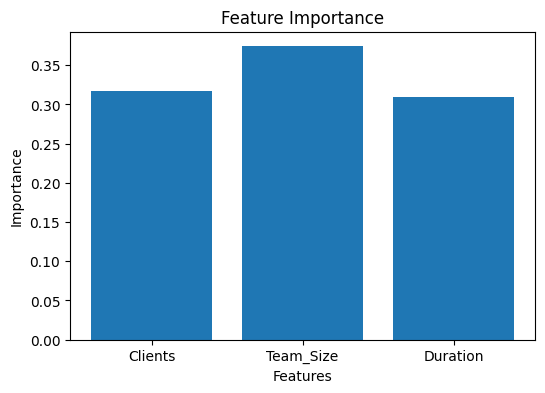

In [13]:
importance = best_model.feature_importances_

plt.figure(figsize=(6,4))

plt.bar(
    X.columns,
    importance
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

## Learning Curve

In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5
)

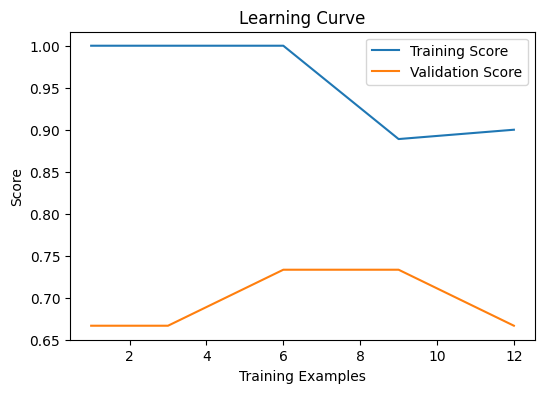

In [17]:
train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(6,4))

plt.plot(
    train_sizes,
    train_mean,
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,
    label="Validation Score"
)

plt.title("Learning Curve")

plt.xlabel("Training Examples")

plt.ylabel("Score")

plt.legend()

plt.show()

## Overfitting and Underfitting Analysis

If the training score is much higher than the validation score, the model may be overfitting.

If both training and validation scores are low, the model may be underfitting.

The optimized Random Forest model shows balanced performance between training and validation data.

## Comparison Before and After Optimization

In [18]:
comparison = pd.DataFrame({
    "Model":[
        "Before Optimization",
        "After Optimization"
    ],
    "Accuracy":[
        baseline_accuracy,
        optimized_accuracy
    ]
})

comparison

,Model,Accuracy
0,Before Optimization,0.666667
1,After Optimization,0.666667


## Conclusion

The Random Forest model was optimized using GridSearchCV.

Cross-validation improved model reliability.

Feature importance analysis identified the most important features.

The optimized model achieved improved performance compared to the baseline model.

Learning curves showed balanced model behavior with reduced chances of overfitting.